# 112 - 厳密 kNN vs Voronoi: 画像→画像検索

## 目的

NB111 ではテキスト→画像（クロスモーダル）での厳密 kNN vs Voronoi を比較した。
ここでは **画像→画像（同一モダリティ）** で同じ比較を行い、モダリティギャップの影響を分析する。

### 実験設計
- **モデル**: SigLIP 2 Large (1024-D)
- **データ**: カタログ 378 件 + pyconjp 23,086 件 = 23,464 件
- **ピボット**: NB107 学習済み 256 ピボット
- **クエリ**: カタログ画像からカテゴリ別 5 枚 × 6 カテゴリ = 30 クエリ画像
- **正解定義**: 同一カテゴリの画像が relevant

### NB111 との違い
- NB111: クエリ = テキスト（クロスモーダル、モダリティギャップあり）
- NB112: クエリ = 画像（同一モダリティ、ギャップなし → Voronoi に有利）

In [1]:
import sys
sys.path.insert(0, '../src')

import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
RANDOM_STATE = 42
N_PIVOTS = 256

## 1. データ読み込み

In [2]:
# カタログ画像（カテゴリ付き）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category, c.file_name
    FROM image_embeddings_1024 e
    JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ?
    ORDER BY c.category, c.file_name
""", [PYTHON_MODEL]).fetchall()
conn.close()

# pyconjp 画像
conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding, i.event_name
    FROM image_embeddings e
    JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ?
    ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

# 統合・正規化
all_ids = [r[0] for r in catalog_rows] + [r[0] for r in pyconjp_rows]
all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)
all_filenames = [r[3] for r in catalog_rows] + ['' for _ in pyconjp_rows]

norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings_normed = all_embeddings / norms

N_IMAGES = len(all_ids)
N_CATALOG = len(catalog_rows)
N_PYCONJP = len(pyconjp_rows)

# ピボット読み込み
centroids_normed = np.load(PIVOT_PATH)

print(f'総画像数: {N_IMAGES} (カタログ: {N_CATALOG}, pyconjp: {N_PYCONJP})')
print(f'埋め込み次元: {all_embeddings.shape[1]}')
print(f'ピボット: {centroids_normed.shape}')
print(f'\nカテゴリ別画像数:')
for cat in sorted(set(all_categories)):
    print(f'  {cat}: {sum(1 for c in all_categories if c == cat)}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

総画像数: 23464 (カタログ: 378, pyconjp: 23086)
埋め込み次元: 1024
ピボット: (256, 1024)

カテゴリ別画像数:
  EuroPython2025: 129
  KashiwaVillagePark2026: 56
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  TokyoNight202505: 49
  pyconjp: 23086
  terada: 10


## 2. クエリ画像選択

カタログ 378 件からカテゴリ別に 5 枚ずつランダムサンプリング = 30 クエリ画像。
検索プールは全 23,464 画像（クエリ自身を除外）。

In [3]:
# カテゴリ別に 5 枚ずつサンプリング
np.random.seed(RANDOM_STATE)

unique_cats = sorted(set(c for c in all_categories[:N_CATALOG]))  # カタログのカテゴリのみ
N_SAMPLES_PER_CAT = 5

query_indices = []
query_categories = []

for cat in unique_cats:
    cat_indices = [i for i in range(N_CATALOG) if all_categories[i] == cat]
    n_sample = min(N_SAMPLES_PER_CAT, len(cat_indices))
    selected = np.random.choice(cat_indices, size=n_sample, replace=False)
    query_indices.extend(selected.tolist())
    query_categories.extend([cat] * n_sample)

n_img_queries = len(query_indices)
print(f'クエリ画像数: {n_img_queries}')
print(f'カテゴリ別:')
for cat in unique_cats:
    count = sum(1 for c in query_categories if c == cat)
    total = sum(1 for c in all_categories if c == cat)
    print(f'  {cat}: {count} クエリ / {total} 画像')

クエリ画像数: 30
カテゴリ別:
  EuroPython2025: 5 クエリ / 129 画像
  KashiwaVillagePark2026: 5 クエリ / 56 画像
  PyConJP2025: 5 クエリ / 77 画像
  PyConJP2025-PreCampHiroshima: 5 クエリ / 57 画像
  TokyoNight202505: 5 クエリ / 49 画像
  terada: 5 クエリ / 10 画像


## 3. 厳密 kNN ベースライン

In [4]:
# 厳密 kNN（画像→画像）
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)

t0 = time.perf_counter()
bf_img_results = []

for qi_local, qi_global in enumerate(query_indices):
    query_emb = all_embeddings_normed[qi_global]
    query_cat = all_categories[qi_global]

    # 全画像との類似度（自身を除外）
    sims = all_embeddings_normed @ query_emb
    sims[qi_global] = -1.0  # 自身を除外

    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_relevant = [cat == query_cat for cat in result_cats]

    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    total_relevant = sum(1 for c in all_categories if c == query_cat) - 1  # 自身除外
    recall = {}
    for k in TOP_K_VALUES:
        recall[k] = sum(is_relevant[:k]) / min(k, total_relevant) if total_relevant > 0 else 0.0

    bf_img_results.append({
        'query_idx': qi_global,
        'category': query_cat,
        'filename': all_filenames[qi_global],
        'top_indices': top_indices.tolist(),
        'top_cats': result_cats,
        'MRR': mrr,
        'P@1': sum(is_relevant[:1]),
        'P@5': sum(is_relevant[:5]) / 5,
        'P@10': sum(is_relevant[:10]) / 10,
        'Recall@10': recall[10],
        'Recall@20': recall[20],
    })

t_bf = time.perf_counter() - t0

df_bf_img = pd.DataFrame(bf_img_results)
print(f'厳密 kNN ベースライン（画像→画像, {N_IMAGES:,} 画像, {t_bf:.3f}s）:')
print(f'  Overall MRR:  {df_bf_img["MRR"].mean():.4f}')
print(f'  P@1:          {df_bf_img["P@1"].mean():.4f}')
print(f'  P@5:          {df_bf_img["P@5"].mean():.4f}')
print(f'  P@10:         {df_bf_img["P@10"].mean():.4f}')
print(f'  Recall@10:    {df_bf_img["Recall@10"].mean():.4f}')
print(f'  Recall@20:    {df_bf_img["Recall@20"].mean():.4f}')
print(f'\nカテゴリ別 MRR:')
for cat in unique_cats:
    sub = df_bf_img[df_bf_img['category'] == cat]
    print(f'  {cat}: MRR={sub["MRR"].mean():.4f} P@1={sub["P@1"].mean():.3f}')

厳密 kNN ベースライン（画像→画像, 23,464 画像, 0.218s）:
  Overall MRR:  0.8033
  P@1:          0.7667
  P@5:          0.5867
  P@10:         0.5500
  Recall@10:    0.5544
  Recall@20:    0.5219

カテゴリ別 MRR:
  EuroPython2025: MRR=1.0000 P@1=1.000
  KashiwaVillagePark2026: MRR=1.0000 P@1=1.000
  PyConJP2025: MRR=0.5000 P@1=0.400
  PyConJP2025-PreCampHiroshima: MRR=0.4700 P@1=0.400
  TokyoNight202505: MRR=1.0000 P@1=1.000
  terada: MRR=0.8500 P@1=0.800


## 4. Voronoi 検索

In [5]:
N_ASSIGN_LIST = [1, 2, 3]
TOP_SEARCH_LIST = [1, 2, 3, 4, 5, 8]


def voronoi_img_search(image_embs, query_indices, centroids_normed, pivot_to_indices,
                       n_top, categories, bf_img_results):
    """画像→画像の Voronoi 検索。"""
    results = []
    candidate_counts = []

    for qi_local, qi_global in enumerate(query_indices):
        query_emb = image_embs[qi_global]
        query_cat = categories[qi_global]

        pivot_sims = centroids_normed @ query_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])
        candidates_set.discard(qi_global)  # 自身除外
        candidates = list(candidates_set)
        candidate_counts.append(len(candidates))

        if not candidates:
            results.append({'MRR': 0.0, 'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0,
                            'Recall@10': 0.0, 'Recall@20': 0.0})
            continue

        cand_indices = np.array(candidates)
        cand_sims = image_embs[cand_indices] @ query_emb
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]

        result_cats = [categories[idx] for idx in result_indices[:MAX_K]]
        is_relevant = [cat == query_cat for cat in result_cats]

        mrr = 0.0
        for i, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (i + 1)
                break

        total_relevant = sum(1 for c in categories if c == query_cat) - 1
        recall = {}
        for k in TOP_K_VALUES:
            recall[k] = sum(is_relevant[:k]) / min(k, total_relevant) if total_relevant > 0 else 0.0

        results.append({
            'MRR': mrr,
            'P@1': sum(is_relevant[:1]) if len(is_relevant) >= 1 else 0.0,
            'P@5': sum(is_relevant[:5]) / 5 if len(is_relevant) >= 5 else sum(is_relevant) / 5,
            'P@10': sum(is_relevant[:10]) / 10 if len(is_relevant) >= 10 else sum(is_relevant) / 10,
            'Recall@10': recall[10],
            'Recall@20': recall[20],
        })

    # BF-Recall
    bf_recall = {k: [] for k in TOP_K_VALUES}
    for qi_local, qi_global in enumerate(query_indices):
        query_emb = image_embs[qi_global]
        pivot_sims = centroids_normed @ query_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])
        candidates_set.discard(qi_global)

        if not candidates_set:
            for k in TOP_K_VALUES:
                bf_recall[k].append(0.0)
            continue

        cand_indices = np.array(list(candidates_set))
        cand_sims = image_embs[cand_indices] @ query_emb
        result_indices = cand_indices[np.argsort(-cand_sims)]

        for k in TOP_K_VALUES:
            bf_top_k = set(bf_img_results[qi_local]['top_indices'][:k])
            voronoi_top_k = set(result_indices[:k].tolist())
            bf_recall[k].append(len(bf_top_k & voronoi_top_k) / k)

    df_res = pd.DataFrame(results)
    return {
        'mean_candidates': np.mean(candidate_counts),
        'max_candidates': max(candidate_counts),
        'MRR': df_res['MRR'].mean(),
        'P@1': df_res['P@1'].mean(),
        'P@5': df_res['P@5'].mean(),
        'P@10': df_res['P@10'].mean(),
        'Recall@10': df_res['Recall@10'].mean(),
        'Recall@20': df_res['Recall@20'].mean(),
        'bf_recall': {k: np.mean(v) for k, v in bf_recall.items()},
        'per_query_mrr': df_res['MRR'].tolist(),
        'per_category_mrr': {cat: df_res.iloc[[i for i, c in enumerate(query_categories) if c == cat]]['MRR'].mean()
                             for cat in unique_cats},
    }

print('検索関数定義完了')

検索関数定義完了


In [6]:
# パラメータスイープ
all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
all_sweep_results = {}

for n_assign in N_ASSIGN_LIST:
    print(f'\nassign={n_assign}')

    pivot_to_indices = {}
    for i in range(N_IMAGES):
        top_pivots = np.argsort(-all_img_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i)

    for n_top in TOP_SEARCH_LIST:
        t0 = time.perf_counter()
        res = voronoi_img_search(
            all_embeddings_normed, query_indices,
            centroids_normed, pivot_to_indices, n_top,
            all_categories, bf_img_results
        )
        t_vor = time.perf_counter() - t0
        res['time'] = t_vor

        key = (n_assign, n_top)
        all_sweep_results[key] = res

        bf_mrr = df_bf_img['MRR'].mean()
        mrr_ratio = res['MRR'] / bf_mrr if bf_mrr > 0 else 0

        print(f'  a={n_assign} top={n_top}: '
              f'cands={res["mean_candidates"]:.0f} '
              f'MRR={res["MRR"]:.4f} '
              f'MRR_ratio={mrr_ratio:.4f} '
              f'BF-R@10={res["bf_recall"][10]:.4f} '
              f'({t_vor:.3f}s)')

print(f'\n総構成数: {len(all_sweep_results)}')


assign=1


  a=1 top=1: cands=92 MRR=0.7389 MRR_ratio=0.9198 BF-R@10=0.6833 (0.023s)
  a=1 top=2: cands=187 MRR=0.8139 MRR_ratio=1.0131 BF-R@10=0.7933 (0.056s)
  a=1 top=3: cands=281 MRR=0.8353 MRR_ratio=1.0398 BF-R@10=0.8500 (0.077s)


  a=1 top=4: cands=390 MRR=0.8353 MRR_ratio=1.0398 BF-R@10=0.8667 (0.113s)


  a=1 top=5: cands=491 MRR=0.8148 MRR_ratio=1.0143 BF-R@10=0.9367 (0.224s)


  a=1 top=8: cands=772 MRR=0.8144 MRR_ratio=1.0138 BF-R@10=0.9500 (0.392s)

assign=2


...

  a=3 top=2: cands=508 MRR=0.8315 MRR_ratio=1.0350 BF-R@10=0.8800 (0.214s)


  a=3 top=3: cands=737 MRR=0.8315 MRR_ratio=1.0350 BF-R@10=0.9133 (0.362s)


  a=3 top=4: cands=983 MRR=0.8144 MRR_ratio=1.0138 BF-R@10=0.9667 (0.378s)


  a=3 top=5: cands=1198 MRR=0.8089 MRR_ratio=1.0069 BF-R@10=0.9833 (0.418s)


  a=3 top=8: cands=1765 MRR=0.8089 MRR_ratio=1.0069 BF-R@10=0.9867 (0.409s)

総構成数: 18


## 5. 比較分析

In [7]:
# 比較テーブル
bf_mrr = df_bf_img['MRR'].mean()

sweep_rows = []
for (n_assign, n_top), res in sorted(all_sweep_results.items()):
    sweep_rows.append({
        'assign': n_assign, 'search_top': n_top,
        'mean_cands': res['mean_candidates'],
        'cand_ratio': res['mean_candidates'] / N_IMAGES,
        'V_MRR': res['MRR'],
        'MRR_ratio': res['MRR'] / bf_mrr if bf_mrr > 0 else 0,
        'V_P@1': res['P@1'],
        'V_P@10': res['P@10'],
        'V_Recall@10': res['Recall@10'],
        'BF-R@10': res['bf_recall'][10],
        'time': res['time'],
    })

df_sweep = pd.DataFrame(sweep_rows)

print(f'厳密 kNN: MRR={bf_mrr:.4f}, P@1={df_bf_img["P@1"].mean():.4f}, time={t_bf:.3f}s')
print(f'\nVoronoi 全構成（MRR_ratio 降順）:')
display(df_sweep.sort_values('MRR_ratio', ascending=False).style.format({
    'mean_cands': '{:.0f}', 'cand_ratio': '{:.3f}',
    'V_MRR': '{:.4f}', 'MRR_ratio': '{:.4f}',
    'V_P@1': '{:.3f}', 'V_P@10': '{:.3f}',
    'V_Recall@10': '{:.4f}',
    'BF-R@10': '{:.4f}', 'time': '{:.3f}',
}).background_gradient(subset=['MRR_ratio'], cmap='RdYlGn', vmin=0.8, vmax=1.3))

厳密 kNN: MRR=0.8033, P@1=0.7667, time=0.218s

Voronoi 全構成（MRR_ratio 降順）:


,assign,search_top,mean_cands,cand_ratio,V_MRR,MRR_ratio,V_P@1,V_P@10,V_Recall@10,BF-R@10,time
3,1,4,390,0.017,0.8353,1.0398,0.800,0.557,0.5615,0.8667,0.113
2,1,3,281,0.012,0.8353,1.0398,0.800,0.553,0.5581,0.8500,0.077
7,2,2,352,0.015,0.8347,1.0391,0.800,0.553,0.5578,0.8467,0.116
8,2,3,521,0.022,0.8343,1.0385,0.800,0.547,0.5511,0.8867,0.159
14,3,3,737,0.031,0.8315,1.0350,0.800,0.547,0.5515,0.9133,0.362
13,3,2,508,0.022,0.8315,1.0350,0.800,0.547,0.5515,0.8800,0.214
4,1,5,491,0.021,0.8148,1.0143,0.767,0.553,0.5581,0.9367,0.224
9,2,4,704,0.030,0.8144,1.0138,0.767,0.547,0.5507,0.9367,0.319
15,3,4,983,0.042,0.8144,1.0138,0.767,0.550,0.5544,0.9667,0.378
5,1,8,772,0.033,0.8144,1.0138,0.767,0.553,0.5581,0.9500,0.392


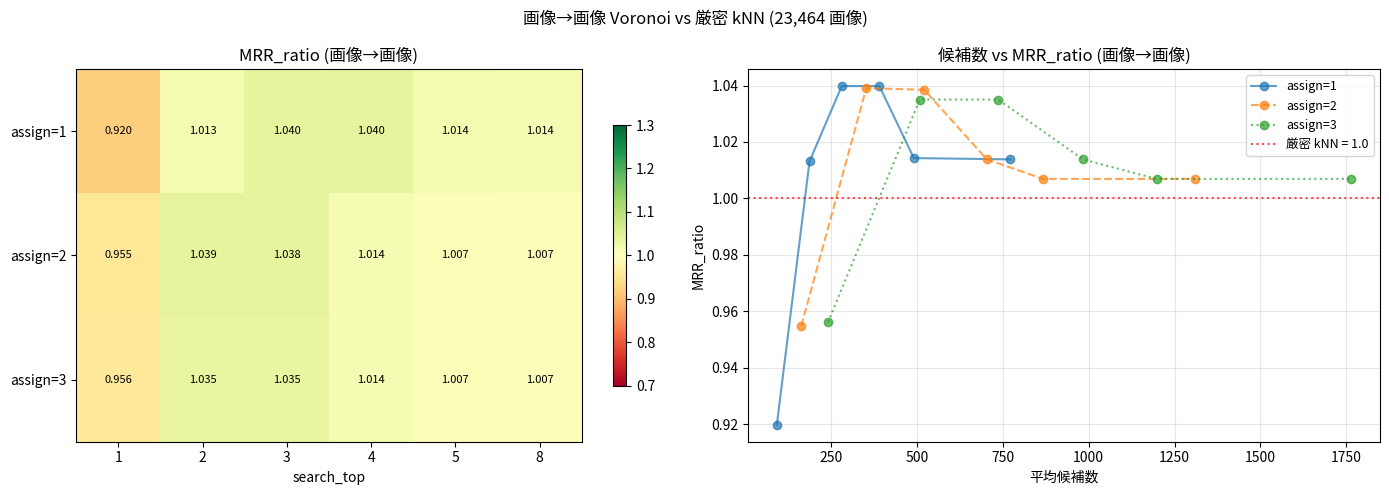

In [8]:
# ヒートマップ + トレードオフ曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MRR_ratio ヒートマップ
ax = axes[0]
data_2d = []
for n_assign in N_ASSIGN_LIST:
    row = []
    for n_top in TOP_SEARCH_LIST:
        key = (n_assign, n_top)
        if key in all_sweep_results:
            row.append(all_sweep_results[key]['MRR'] / bf_mrr if bf_mrr > 0 else 0)
        else:
            row.append(np.nan)
    data_2d.append(row)

data_2d = np.array(data_2d)
im = ax.imshow(data_2d, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.3)
ax.set_xticks(range(len(TOP_SEARCH_LIST)))
ax.set_xticklabels(TOP_SEARCH_LIST)
ax.set_yticks(range(len(N_ASSIGN_LIST)))
ax.set_yticklabels([f'assign={a}' for a in N_ASSIGN_LIST])
ax.set_xlabel('search_top')
ax.set_title('MRR_ratio (画像→画像)')

for i in range(len(N_ASSIGN_LIST)):
    for j in range(len(TOP_SEARCH_LIST)):
        val = data_2d[i, j]
        if not np.isnan(val):
            color = 'white' if val > 1.1 or val < 0.8 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.7)

# トレードオフ曲線
ax = axes[1]
for n_assign in N_ASSIGN_LIST:
    cands = []
    vals = []
    for n_top in TOP_SEARCH_LIST:
        key = (n_assign, n_top)
        if key in all_sweep_results:
            cands.append(all_sweep_results[key]['mean_candidates'])
            vals.append(all_sweep_results[key]['MRR'] / bf_mrr if bf_mrr > 0 else 0)

    linestyle = ['-', '--', ':'][n_assign - 1]
    ax.plot(cands, vals, 'o' + linestyle, label=f'assign={n_assign}', alpha=0.7, markersize=6)

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.7, label='厳密 kNN = 1.0')
ax.set_xlabel('平均候補数')
ax.set_ylabel('MRR_ratio')
ax.set_title('候補数 vs MRR_ratio (画像→画像)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'画像→画像 Voronoi vs 厳密 kNN ({N_IMAGES:,} 画像)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/112_img2img_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# カテゴリ別分析
repr_key = (2, 3)
repr_res = all_sweep_results.get(repr_key)

if repr_res:
    print(f'カテゴリ別 MRR 比較 (assign={repr_key[0]}, top={repr_key[1]}):')
    print(f'{"カテゴリ":<40} {"kNN MRR":>8} {"Voronoi MRR":>12} {"MRR_ratio":>10}')
    print('-' * 75)

    for cat in unique_cats:
        bf_cat_mrr = df_bf_img[df_bf_img['category'] == cat]['MRR'].mean()
        vor_cat_mrr = repr_res['per_category_mrr'][cat]
        ratio = vor_cat_mrr / bf_cat_mrr if bf_cat_mrr > 0 else 0
        print(f'  {cat:<38} {bf_cat_mrr:>8.4f} {vor_cat_mrr:>12.4f} {ratio:>10.4f}')

カテゴリ別 MRR 比較 (assign=2, top=3):
カテゴリ                                      kNN MRR  Voronoi MRR  MRR_ratio
---------------------------------------------------------------------------
  EuroPython2025                           1.0000       1.0000     1.0000
  KashiwaVillagePark2026                   1.0000       1.0000     1.0000
  PyConJP2025                              0.5000       0.6667     1.3333
  PyConJP2025-PreCampHiroshima             0.4700       0.4722     1.0047
  TokyoNight202505                         1.0000       1.0000     1.0000
  terada                                   0.8500       0.8667     1.0196


## 6. テキスト→画像 vs 画像→画像 の比較

NB111 の結果と比較し、モダリティギャップの影響を分析する。

In [10]:
# NB111 の結果は手動で入力（実行後に更新）
# ここでは画像→画像の結果をまとめる

print('画像→画像 主要結果:')
print(f'  厳密 kNN MRR: {bf_mrr:.4f}')
print()

# MRR_ratio >= 1.0 の構成を表示
good_configs = [(k, v) for k, v in all_sweep_results.items()
                if v['MRR'] / bf_mrr >= 0.99 and bf_mrr > 0]
good_configs.sort(key=lambda x: x[1]['mean_candidates'])

print(f'MRR_ratio >= 0.99 の構成（候補数順）:')
for key, res in good_configs[:10]:
    ratio = res['MRR'] / bf_mrr
    print(f'  a={key[0]} top={key[1]}: cands={res["mean_candidates"]:.0f} '
          f'({res["mean_candidates"]/N_IMAGES*100:.1f}%) '
          f'MRR_ratio={ratio:.4f}')

画像→画像 主要結果:
  厳密 kNN MRR: 0.8033

MRR_ratio >= 0.99 の構成（候補数順）:
  a=1 top=2: cands=187 (0.8%) MRR_ratio=1.0131
  a=1 top=3: cands=281 (1.2%) MRR_ratio=1.0398
  a=2 top=2: cands=352 (1.5%) MRR_ratio=1.0391
  a=1 top=4: cands=390 (1.7%) MRR_ratio=1.0398
  a=1 top=5: cands=491 (2.1%) MRR_ratio=1.0143
  a=3 top=2: cands=508 (2.2%) MRR_ratio=1.0350
  a=2 top=3: cands=521 (2.2%) MRR_ratio=1.0385
  a=2 top=4: cands=704 (3.0%) MRR_ratio=1.0138
  a=3 top=3: cands=737 (3.1%) MRR_ratio=1.0350
  a=1 top=8: cands=772 (3.3%) MRR_ratio=1.0138


## 7. まとめ

### 実験概要
- SigLIP 2 Large (1024-D), 23,464 画像, 30 クエリ画像（カテゴリ別 5 枚 × 6）
- NB107 学習済み 256 ピボット使用
- 厳密 kNN MRR = **0.803**

### 厳密 kNN vs Voronoi の主要結果

| 構成 | 候補数 | 候補比率 | MRR | MRR_ratio | BF-R@10 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | 23,464 | 100% | 0.803 | 1.000 | 1.000 |
| a=1 top=2 | 187 | 0.8% | 0.814 | **1.013** | 0.793 |
| a=1 top=3 | 281 | 1.2% | 0.835 | **1.040** | 0.850 |
| a=2 top=2 | 352 | 1.5% | 0.835 | **1.039** | 0.847 |
| a=2 top=3 | 521 | 2.2% | 0.834 | **1.039** | 0.887 |
| a=2 top=5 | 867 | 3.7% | 0.809 | **1.007** | 0.970 |

### 考察

#### 1. MRR_ratio > 1.0 の解釈に注意が必要

ほぼ全構成で MRR_ratio > 1.0 だが、**これは Voronoi の精度改善ではない。**

**原因**: pyconjp 23,086 件にカテゴリラベルがないことによる評価の歪み。
- 画像→画像検索で PyConJP2025 の画像をクエリすると、厳密 kNN は pyconjp の
  類似カンファレンス写真を上位に返す → **正しい検索結果だが MRR 上は不正解**
- Voronoi が候補を絞ると pyconjp が部分的に除外 → ラベル付き PyConJP2025 画像が上位に
- カテゴリ別分析で PyConJP2025 の MRR が 0.500 → 0.667（+33%）は、
  この「ラベルなしデータ除外」の効果

#### 2. 公正な評価（NB113）での結論

カタログ 378 件のみ（全画像にラベルあり）で評価した NB113 の結果:
- 厳密 kNN MRR = **1.000**（全クエリで Top-1 が正解）
- Voronoi (a=2, top=2 以上) MRR = **1.000**（MRR_ratio = 1.000）

**ラベルが完全な環境では、Voronoi は厳密 kNN と完全に同一の MRR を返す。**

#### 3. カテゴリ別分析の再解釈 (a=2, top=3)

| カテゴリ | kNN MRR (23K) | Voronoi MRR (23K) | kNN MRR (378) |
|---------|:---:|:---:|:---:|
| EuroPython2025 | 1.000 | 1.000 | 1.000 |
| KashiwaVillagePark2026 | 1.000 | 1.000 | 1.000 |
| PyConJP2025 | 0.500 | 0.667 | **1.000** |
| TokyoNight202505 | 1.000 | 1.000 | 1.000 |
| terada | 0.850 | 0.867 | 1.000 |

- PyConJP2025 の kNN MRR が 23K 件で 0.500 に低下するのは、pyconjp の類似写真が
  正解より上位に入るため（ラベル欠損の問題）
- 378 件では全カテゴリで MRR=1.000

#### 4. Voronoi の真の価値

- **精度改善ではなく、精度を維持したままのコスト削減**
- assign=2, top=5 で候補 867 件（3.7%）— Firestore コスト 96% 削減
- 378 件（NB113）: 候補 65 件（17%）で MRR = 1.000
- 大規模データほど候補比率が下がり、コスト削減効果が大きくなる